# Step 1: Preprocess WFI2033 Data

目标：
- 以 `(x=2116, y=3377)` 为中心裁切 `200x200`
- 用四个 corner 的 `5x5` 像素估计背景噪声（MAD）
- 生成一个双扩展 FITS：第 1 张数据（SCI），第 2 张误差（ERR）

In [1]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt

# ---- Config ----
DATA_DIR = Path('../../Data/WFI2033')
INPUT_FITS = DATA_DIR / 'jw01198-o004_t004_nircam_clear-f115w_i2d.fits'
X_CENTER, Y_CENTER = 6985, 3594
CUT_SIZE = (150, 150)  # (ny, nx)
CORNER_N = 5
OUTPUT_FITS = DATA_DIR / f'jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x{X_CENTER}_y{Y_CENTER}_150.fits'

print('INPUT_FITS =', INPUT_FITS)
print('OUTPUT_FITS =', OUTPUT_FITS)

INPUT_FITS = ../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d.fits
OUTPUT_FITS = ../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x6985_y3594_150.fits


In [2]:
with fits.open(INPUT_FITS, memmap=True) as hdul:
    sci_hdu = hdul['SCI']
    err_hdu = hdul['ERR']

    sci = sci_hdu.data.astype(np.float64)
    err = err_hdu.data.astype(np.float64)

    cut_sci = Cutout2D(sci, position=(X_CENTER, Y_CENTER), size=CUT_SIZE, wcs=WCS(sci_hdu.header), mode='strict')
    cut_err = Cutout2D(err, position=(X_CENTER, Y_CENTER), size=CUT_SIZE, wcs=WCS(err_hdu.header), mode='strict')

    sci_cut = cut_sci.data
    err_cut = cut_err.data

valid = np.isfinite(sci_cut) & np.isfinite(err_cut) & (err_cut > 0)
if valid.sum() == 0:
    raise RuntimeError('No valid finite pixels in SCI/ERR cutout.')

# ---- Save one FITS with two image extensions (SCI + ERR) ----
wcs_hdr = cut_sci.wcs.to_header(relax=True)

sci_hdr = sci_hdu.header.copy()
sci_hdr.update(wcs_hdr)
sci_hdr['EXTNAME'] = 'SCI'
sci_hdr['CUTX'] = (X_CENTER, 'Cutout center x (0-based pixel index)')
sci_hdr['CUTY'] = (Y_CENTER, 'Cutout center y (0-based pixel index)')
sci_hdr['CUTSIZE'] = (CUT_SIZE[0], 'Cutout size in pixels')

err_hdr = err_hdu.header.copy()
err_hdr.update(wcs_hdr)
err_hdr['EXTNAME'] = 'ERR'
err_hdr['CUTX'] = (X_CENTER, 'Cutout center x (0-based pixel index)')
err_hdr['CUTY'] = (Y_CENTER, 'Cutout center y (0-based pixel index)')
err_hdr['CUTSIZE'] = (CUT_SIZE[0], 'Cutout size in pixels')

hdul_out = fits.HDUList([
    fits.PrimaryHDU(),
    fits.ImageHDU(data=sci_cut.astype(np.float32), header=sci_hdr, name='SCI'),
    fits.ImageHDU(data=err_cut.astype(np.float32), header=err_hdr, name='ERR'),
])
hdul_out.writeto(OUTPUT_FITS, overwrite=True)

print('Saved:', OUTPUT_FITS)
print('SCI shape:', sci_cut.shape)
print('ERR shape:', err_cut.shape)
print('Valid pixels:', int(valid.sum()))


Saved: ../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x6985_y3594_150.fits
SCI shape: (150, 150)
ERR shape: (150, 150)
Valid pixels: 22500


Set DATE-AVG to '2022-09-19T05:29:32.024' from MJD-AVG.
Set DATE-END to '2022-09-19T05:46:53.553' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     0.765830 from OBSGEO-[XYZ].
Set OBSGEO-H to 1311263769.644 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


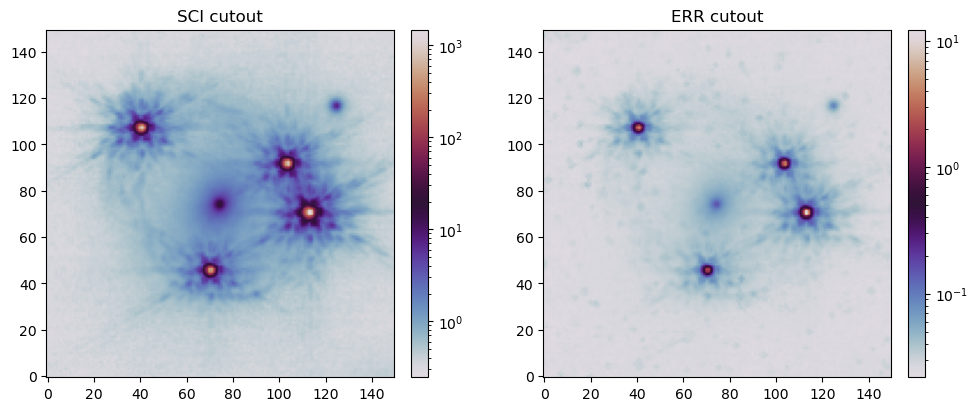

In [3]:
# Show cutout with requested display style
sci_show = np.where(sci_cut > 0, sci_cut, np.nan)
err_show = np.where(err_cut > 0, err_cut, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(sci_show, origin='lower', norm='log', cmap='twilight')
axes[0].set_title('SCI cutout')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(err_show, origin='lower', norm='log', cmap='twilight')
axes[1].set_title('ERR cutout')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()
